# Compare MAGNET incremental phases (legacy / B / C)

Loads timing JSON + forecast catalogs from `runnable_code/benchmark_magnet_incremental.py`.

Setup: **5 realizations**, **100-day** forecast window, phases `legacy`, `phase_b`, `phase_c`
(event-capped for tractable wall times).

Forecast panels mirror the ensemble notebook: paired metrics, cumulative N(t),
rate, pooled magnitude / interevent distributions, and mag–time / map scatter.

In [5]:
%matplotlib inline
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

PHASE_ORDER = ("legacy", "phase_b", "phase_c", "phase_a")
PHASE_COLORS = {
    "legacy": "#6a645a",
    "phase_a": "#2f5d8c",
    "phase_b": "#0b6e4f",
    "phase_c": "#b35c1e",
}


def find_repo_root() -> Path:
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "benchmark_magnet_incremental.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError("Could not find etas_magnet-incremental repo root")


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


REPO = find_repo_root()
TIMING = REPO / "outputs" / "magnet_incremental_phase_timing.json"
assert TIMING.is_file(), f"Missing {TIMING}. Run the benchmark first."


In [6]:
data = json.loads(TIMING.read_text())
phases = [p for p in PHASE_ORDER if p in data["phases"]]
print("model:", data["model_dir"])
print(
    f"history={data['history_size']}  forecast_days={data['forecast_days']}  "
    f"max_forecast_events={data['max_forecast_events']}  n_runs={data['n_runs']}"
)
print("phases:", phases)

timing_rows = []
for phase in phases:
    block = data["phases"][phase]
    for run in block["runs"]:
        timing_rows.append(
            {
                "phase": phase,
                "label": block["label"],
                "run": run["run"],
                "seed": run["seed"],
                "elapsed_s": run["elapsed_s"],
                "n_events": run["n_events"],
            }
        )
timing_df = pd.DataFrame(timing_rows)
timing_summary = (
    timing_df.groupby(["phase", "label"], sort=False)
    .agg(
        mean_s=("elapsed_s", "mean"),
        std_s=("elapsed_s", "std"),
        min_s=("elapsed_s", "min"),
        max_s=("elapsed_s", "max"),
        mean_events=("n_events", "mean"),
    )
    .reset_index()
)
timing_summary


model: /home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction/results/trained_models/Hauksson
history=80  forecast_days=100.0  max_forecast_events=500  n_runs=5
phases: ['legacy', 'phase_b', 'phase_c']


,phase,label,mean_s,std_s,min_s,max_s,mean_events
0,legacy,Legacy (INCREMENTAL_ENCODERS=0),50.723671,0.311480,50.432432,51.234299,500.0
1,phase_b,Phase B (feature state recompute),46.247859,0.339391,45.840537,46.772062,500.0
2,phase_c,Phase C (sliding / spatial hash),46.295379,0.389343,45.717825,46.703895,500.0


## Wall-clock timing

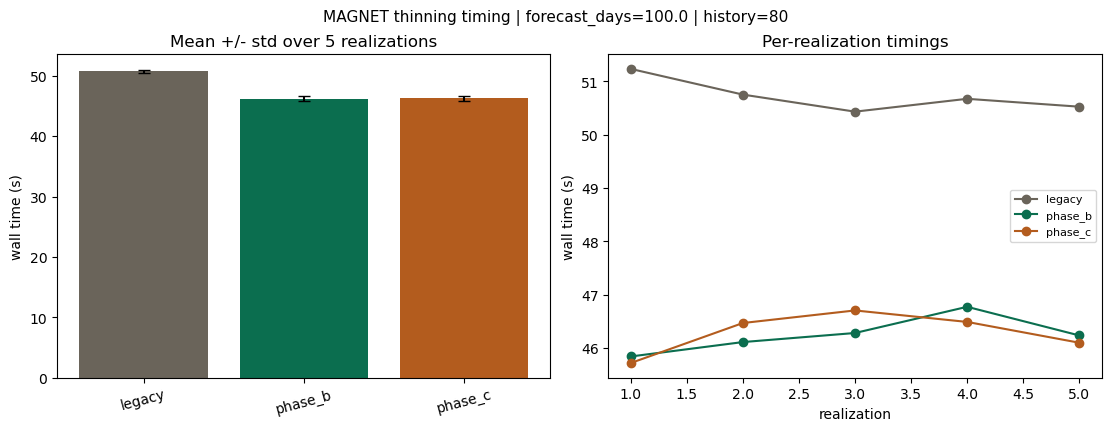

legacy / phase_c = 1.10x
legacy / phase_b = 1.10x
phase_b / phase_c = 1.00x


In [7]:
means = [data["phases"][p]["mean_s"] for p in phases]
stds = [data["phases"][p]["std_s"] for p in phases]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
ax = axes[0]
x = range(len(phases))
ax.bar(
    x,
    means,
    yerr=stds,
    capsize=4,
    color=[PHASE_COLORS.get(p, "C0") for p in phases],
)
ax.set_xticks(list(x))
ax.set_xticklabels(phases, rotation=15)
ax.set_ylabel("wall time (s)")
ax.set_title(f"Mean +/- std over {data['n_runs']} realizations")

ax = axes[1]
for phase in phases:
    sub = timing_df[timing_df.phase == phase]
    ax.plot(sub["run"] + 1, sub["elapsed_s"], marker="o", color=PHASE_COLORS[phase], label=phase)
ax.set_xlabel("realization")
ax.set_ylabel("wall time (s)")
ax.set_title("Per-realization timings")
ax.legend(fontsize=8)
fig.suptitle(
    f"MAGNET thinning timing | forecast_days={data['forecast_days']} | "
    f"history={data['history_size']}",
    fontsize=11,
)
show_fig(fig)

if "legacy" in data["phases"] and "phase_c" in data["phases"]:
    leg = data["phases"]["legacy"]["mean_s"]
    c = data["phases"]["phase_c"]["mean_s"]
    b = data["phases"].get("phase_b", {}).get("mean_s")
    if c:
        print(f"legacy / phase_c = {leg / c:.2f}x")
    if b and c:
        print(f"legacy / phase_b = {leg / b:.2f}x")
        print(f"phase_b / phase_c = {b / c:.2f}x")


## Load forecast catalogs

Expects `catalog_root` from the timing JSON (`outputs/magnet_incremental_phase_catalogs/...`).
Re-run the benchmark if catalogs are missing.

In [8]:
def _normalize_forecast(df: pd.DataFrame, *, t0: pd.Timestamp) -> pd.DataFrame:
    out = df.copy()
    if "magnitude" not in out.columns and "m" in out.columns:
        out["magnitude"] = out["m"]
    if "longitude" not in out.columns and "x" in out.columns:
        out["longitude"] = out["x"]
    if "latitude" not in out.columns and "y" in out.columns:
        out["latitude"] = out["y"]
    if "time" not in out.columns and "t" in out.columns:
        # thinning internal days since epoch
        out["time"] = pd.to_datetime(out["t"], unit="D", origin="unix")
    else:
        out["time"] = pd.to_datetime(out["time"], utc=False)
    out["dt_days"] = (out["time"] - t0) / pd.Timedelta(days=1)
    out = out.sort_values("time").reset_index(drop=True)
    return out


def interevent_times(dt_days: np.ndarray) -> np.ndarray:
    dt_days = np.sort(np.asarray(dt_days, dtype=float))
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(dt_days)


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    dt_days = np.asarray(dt_days, dtype=float)
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


catalog_root = Path(data.get("catalog_root", REPO / "outputs" / "magnet_incremental_phase_catalogs"))
history_path = Path(data.get("history_catalog", catalog_root / "history_catalog.csv"))
assert catalog_root.is_dir(), (
    f"Missing catalog root {catalog_root}. Re-run benchmark_magnet_incremental.py "
    "(it now writes forecast CSVs per phase/seed)."
)

history = pd.read_csv(history_path)
history["time"] = pd.to_datetime(history["time"])
t0 = history["time"].max()
forecast_days = float(data["forecast_days"])

catalogs_by_phase: dict[str, dict[int, pd.DataFrame]] = {}
for phase in phases:
    catalogs_by_phase[phase] = {}
    for run in data["phases"][phase]["runs"]:
        seed = int(run["seed"])
        path = Path(run.get("forecast_catalog", catalog_root / phase / f"seed_{seed}" / "forecast_catalog.csv"))
        assert path.is_file(), f"Missing forecast catalog: {path}"
        catalogs_by_phase[phase][seed] = _normalize_forecast(pd.read_csv(path), t0=t0)

print(f"t0 (auxiliary_end) = {t0}")
for phase in phases:
    n = [len(c) for c in catalogs_by_phase[phase].values()]
    print(f"  {phase}: {len(n)} seeds, event counts {min(n)}–{max(n)}")


t0 (auxiliary_end) = 1971-12-13 00:16:30.526508799
  legacy: 5 seeds, event counts 500–500
  phase_b: 5 seeds, event counts 500–500
  phase_c: 5 seeds, event counts 500–500


## Per-realization metrics (paired by seed)

,seed,legacy_n_events,legacy_max_magnitude,legacy_median_iet_days,phase_b_n_events,phase_b_max_magnitude,phase_b_median_iet_days,phase_c_n_events,phase_c_max_magnitude,phase_c_median_iet_days
count,5.000000,5.0,5.000000,5.000000,5.0,5.000000,5.000000,5.0,5.000000,5.000000
mean,44.000000,500.0,5.723403,0.003294,500.0,5.723403,0.003294,500.0,5.723403,0.003294
std,1.581139,0.0,0.653488,0.001991,0.0,0.653488,0.001991,0.0,0.653488,0.001991
min,42.000000,500.0,4.993372,0.001818,500.0,4.993372,0.001818,500.0,4.993372,0.001818
25%,43.000000,500.0,5.082643,0.001995,500.0,5.082643,0.001995,500.0,5.082643,0.001995
50%,44.000000,500.0,5.877042,0.002072,500.0,5.877042,0.002072,500.0,5.877042,0.002072
75%,45.000000,500.0,6.319010,0.004175,500.0,6.319010,0.004175,500.0,6.319010,0.004175
max,46.000000,500.0,6.344946,0.006411,500.0,6.344946,0.006411,500.0,6.344946,0.006411


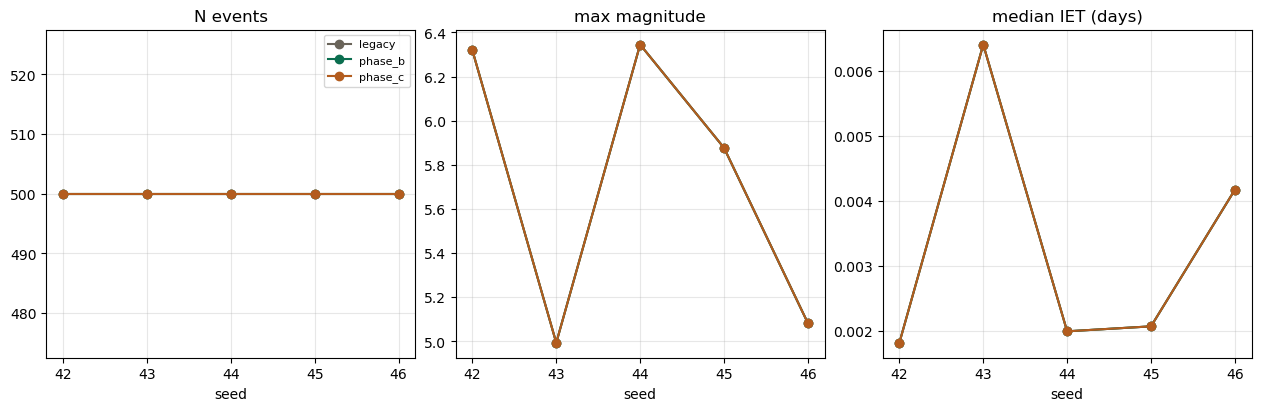

,seed,legacy_n_events,legacy_max_magnitude,legacy_median_iet_days,phase_b_n_events,phase_b_max_magnitude,phase_b_median_iet_days,phase_c_n_events,phase_c_max_magnitude,phase_c_median_iet_days
0,42,500,6.319010,0.001818,500,6.319010,0.001818,500,6.319010,0.001818
1,43,500,4.993372,0.006411,500,4.993372,0.006411,500,4.993372,0.006411
2,44,500,6.344946,0.001995,500,6.344946,0.001995,500,6.344946,0.001995
3,45,500,5.877042,0.002072,500,5.877042,0.002072,500,5.877042,0.002072
4,46,500,5.082643,0.004175,500,5.082643,0.004175,500,5.082643,0.004175


In [9]:
seeds = sorted({s for phase in phases for s in catalogs_by_phase[phase]})
paired = pd.DataFrame({"seed": seeds})
for phase in phases:
    n_events, max_m, med_iet = [], [], []
    for seed in seeds:
        cat = catalogs_by_phase[phase][seed]
        n_events.append(len(cat))
        max_m.append(float(cat["magnitude"].max()) if len(cat) else np.nan)
        iet = interevent_times(cat["dt_days"].to_numpy())
        med_iet.append(float(np.median(iet)) if iet.size else np.nan)
    paired[f"{phase}_n_events"] = n_events
    paired[f"{phase}_max_magnitude"] = max_m
    paired[f"{phase}_median_iet_days"] = med_iet

display(paired.describe())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), constrained_layout=True)
metrics = [
    ("n_events", "N events"),
    ("max_magnitude", "max magnitude"),
    ("median_iet_days", "median IET (days)"),
]
for ax, (key, title) in zip(axes, metrics):
    for phase in phases:
        ax.plot(
            paired["seed"],
            paired[f"{phase}_{key}"],
            marker="o",
            color=PHASE_COLORS[phase],
            label=phase,
        )
    ax.set_title(title)
    ax.set_xlabel("seed")
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8)
show_fig(fig)
paired


## Tier 1 — cumulative count and rate

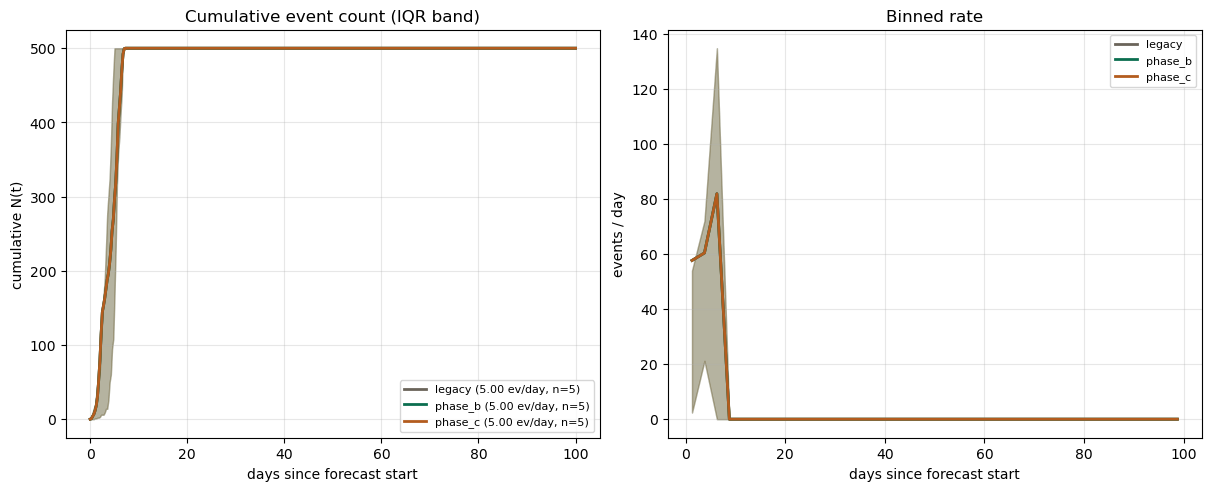

In [10]:
t_max = max(
    float(cat["dt_days"].max())
    for phase in phases
    for cat in catalogs_by_phase[phase].values()
    if len(cat)
)
t_max = max(t_max, forecast_days)
t_grid = np.linspace(0.0, t_max, 400)
bin_edges = np.linspace(0.0, t_max, 41)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = float(np.diff(bin_edges).mean())

curves = {}
rates = {}
slopes = {}
for phase in phases:
    cum = np.vstack(
        [
            cumulative_on_grid(cat["dt_days"].to_numpy(), t_grid)
            for cat in catalogs_by_phase[phase].values()
        ]
    )
    rate = np.vstack(
        [
            np.histogram(cat["dt_days"].to_numpy(), bins=bin_edges)[0].astype(float) / bin_width
            for cat in catalogs_by_phase[phase].values()
        ]
    )
    curves[phase] = cum
    rates[phase] = rate
    slopes[phase] = float(cum[:, -1].mean() / max(t_max, 1e-9))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
ax = axes[0]
for phase in phases:
    arr = curves[phase]
    mean = arr.mean(axis=0)
    q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
    color = PHASE_COLORS[phase]
    ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2)
    ax.plot(
        t_grid,
        mean,
        color=color,
        lw=2,
        label=f"{phase} ({slopes[phase]:.2f} ev/day, n={arr.shape[0]})",
    )
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative N(t)")
ax.set_title("Cumulative event count (IQR band)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for phase in phases:
    arr = rates[phase]
    mean = arr.mean(axis=0)
    q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
    color = PHASE_COLORS[phase]
    ax.fill_between(bin_centers, q25, q75, color=color, alpha=0.2)
    ax.plot(bin_centers, mean, color=color, lw=2, label=phase)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events / day")
ax.set_title("Binned rate")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
show_fig(fig)


## Tier 2 — pooled magnitude and interevent-time distributions

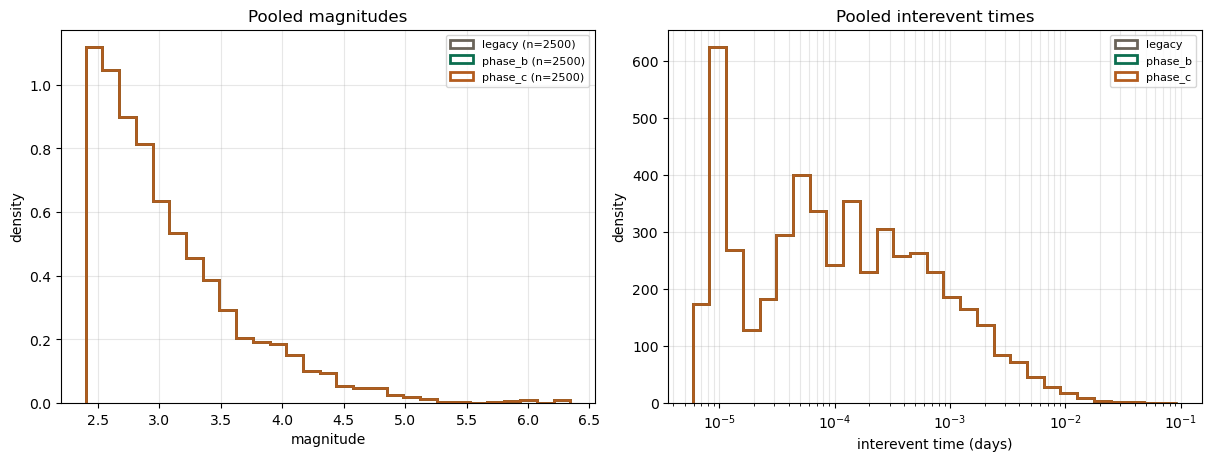

,comparison,quantity,ks_stat,p_value
0,legacy vs phase_b,magnitude,0.0,1.0
1,legacy vs phase_b,interevent time,0.0,1.0
2,legacy vs phase_c,magnitude,0.0,1.0
3,legacy vs phase_c,interevent time,0.0,1.0
4,phase_b vs phase_c,magnitude,0.0,1.0
5,phase_b vs phase_c,interevent time,0.0,1.0


In [11]:
pooled_m = {
    phase: np.concatenate([c["magnitude"].to_numpy(dtype=float) for c in catalogs_by_phase[phase].values()])
    for phase in phases
}
pooled_iet = {
    phase: np.concatenate(
        [interevent_times(c["dt_days"].to_numpy()) for c in catalogs_by_phase[phase].values()]
    )
    for phase in phases
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
ax = axes[0]
m_lo = min(float(np.min(v)) for v in pooled_m.values() if v.size)
m_hi = max(float(np.max(v)) for v in pooled_m.values() if v.size)
bins_m = np.linspace(m_lo, m_hi, 30)
for phase in phases:
    ax.hist(
        pooled_m[phase],
        bins=bins_m,
        density=True,
        histtype="step",
        lw=2,
        color=PHASE_COLORS[phase],
        label=f"{phase} (n={pooled_m[phase].size})",
    )
ax.set_xlabel("magnitude")
ax.set_ylabel("density")
ax.set_title("Pooled magnitudes")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
iet_pos = [pooled_iet[p][pooled_iet[p] > 0] for p in phases]
iet_lo = min(float(np.min(v)) for v in iet_pos if v.size)
iet_hi = max(float(np.quantile(v, 0.99)) for v in iet_pos if v.size)
bins_iet = np.geomspace(max(iet_lo, 1e-6), iet_hi, 30)
for phase in phases:
    vals = pooled_iet[phase]
    vals = vals[vals > 0]
    ax.hist(
        vals,
        bins=bins_iet,
        density=True,
        histtype="step",
        lw=2,
        color=PHASE_COLORS[phase],
        label=phase,
    )
ax.set_xscale("log")
ax.set_xlabel("interevent time (days)")
ax.set_ylabel("density")
ax.set_title("Pooled interevent times")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")
show_fig(fig)

rows = []
for i, a in enumerate(phases):
    for b in phases[i + 1 :]:
        for name, store in [("magnitude", pooled_m), ("interevent time", pooled_iet)]:
            xa, xb = store[a], store[b]
            if name == "interevent time":
                xa, xb = xa[xa > 0], xb[xb > 0]
            if xa.size < 2 or xb.size < 2:
                continue
            ks = stats.ks_2samp(xa, xb)
            rows.append(
                {
                    "comparison": f"{a} vs {b}",
                    "quantity": name,
                    "ks_stat": float(ks.statistic),
                    "p_value": float(ks.pvalue),
                }
            )
pd.DataFrame(rows)


## Realization view — magnitude vs time and map

Uses the first common seed (same RNG seed across phases).

Showing seed=42


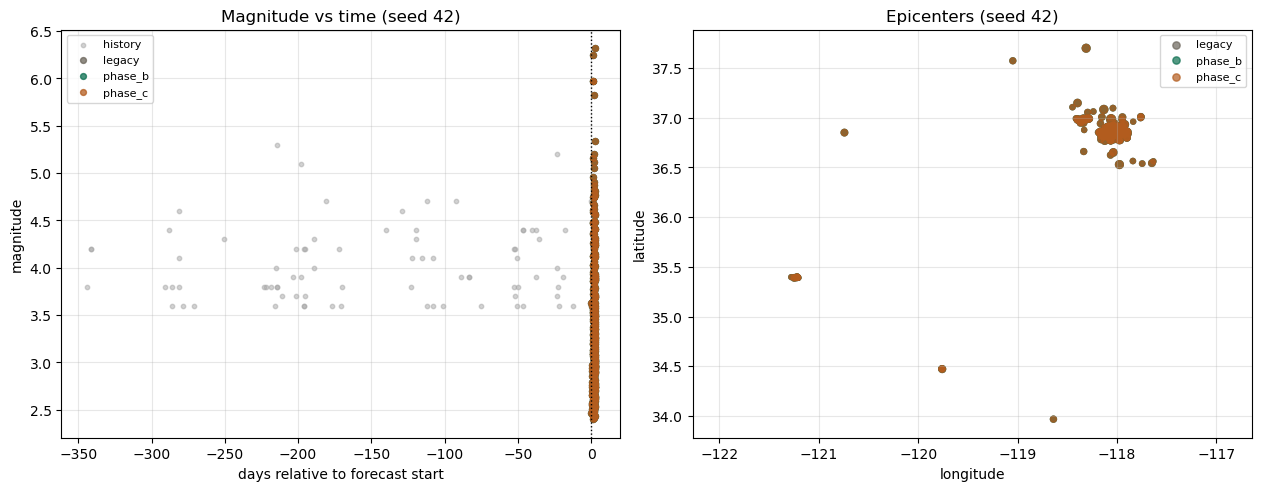

,pair,same_len,mag_equal,time_equal
0,legacy vs phase_b,True,True,True
1,legacy vs phase_c,True,True,True
2,phase_b vs phase_c,True,True,True


In [12]:
seed0 = seeds[0]
print(f"Showing seed={seed0}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
ax = axes[0]
hist_dt = (history["time"] - t0) / pd.Timedelta(days=1)
ax.scatter(
    hist_dt,
    history["magnitude"] if "magnitude" in history.columns else history.get("m"),
    s=10,
    c="0.65",
    alpha=0.5,
    label="history",
    zorder=1,
)
for phase in phases:
    cat = catalogs_by_phase[phase][seed0]
    ax.scatter(
        cat["dt_days"],
        cat["magnitude"],
        s=18,
        alpha=0.75,
        color=PHASE_COLORS[phase],
        label=phase,
        zorder=2,
    )
ax.axvline(0.0, color="k", ls=":", lw=1)
ax.set_xlabel("days relative to forecast start")
ax.set_ylabel("magnitude")
ax.set_title(f"Magnitude vs time (seed {seed0})")
ax.legend(fontsize=8, loc="best")
ax.grid(True, alpha=0.3)

ax = axes[1]
for phase in phases:
    cat = catalogs_by_phase[phase][seed0]
    ax.scatter(
        cat["longitude"],
        cat["latitude"],
        s=12 + 8 * (cat["magnitude"] - cat["magnitude"].min()),
        alpha=0.7,
        color=PHASE_COLORS[phase],
        label=phase,
    )
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"Epicenters (seed {seed0})")
ax.legend(fontsize=8)
ax.set_aspect("equal", adjustable="datalim")
ax.grid(True, alpha=0.3)
show_fig(fig)

# Exact catalog identity for this seed (expected True for B vs C / legacy when RNG aligned)
rows = []
for i, a in enumerate(phases):
    for b in phases[i + 1 :]:
        ca, cb = catalogs_by_phase[a][seed0], catalogs_by_phase[b][seed0]
        same_len = len(ca) == len(cb)
        mag_eq = same_len and np.allclose(ca["magnitude"], cb["magnitude"], equal_nan=True)
        time_eq = same_len and np.allclose(
            ca["dt_days"].to_numpy(dtype=float),
            cb["dt_days"].to_numpy(dtype=float),
            rtol=0,
            atol=1e-9,
            equal_nan=True,
        )
        rows.append({"pair": f"{a} vs {b}", "same_len": same_len, "mag_equal": mag_eq, "time_equal": time_eq})
pd.DataFrame(rows)


### Re-run benchmark (writes timing JSON + forecast CSVs)

```bash
cd /path/to/etas_magnet-incremental
export PYTHONPATH="$PWD:$PWD/runnable_code:/path/to/eq_mag_prediction_clean"
python runnable_code/benchmark_magnet_incremental.py \
  --phases legacy,phase_b,phase_c --n-runs 5 --forecast-days 100 \
  --max-forecast-events 500 --skip-parity \
  --out outputs/magnet_incremental_phase_timing.json
```